In [4]:
import os
import pandas as pd
import numpy as np
import gdown

# Define Google Drive Shared File ID

FILE_ID = '1UiIqB9ea7WKgt0AIWQrwxWE6lJ96YbDz'
OUTPUT_FILE = 'customer_churn_dataset.csv'

#  Download dataset automatically if not already present
if not os.path.exists(OUTPUT_FILE):
    print("Downloading dataset from Google Drive...")
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    gdown.download(url, OUTPUT_FILE, quiet=False)

# Load dataset
df = pd.read_csv(OUTPUT_FILE)

# Display initial dataset summary
print("\n" + "="*40)
print("     DATASET LOADED SUCCESSFULLY      ")
print("="*40)
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Samples: {X_train.shape[0]:,}")
print(f"Testing Samples:  {X_test.shape[0]:,}")


     DATASET LOADED SUCCESSFULLY      
Dataset Shape: 440,833 rows, 12 columns

--- First 5 Rows ---


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0



--- Missing Values Check ---
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
Training Samples: 352,665
Testing Samples:  88,167


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#  Data Cleaning
df_clean = df.dropna(subset=['Churn']).copy()
if 'CustomerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['CustomerID'])

# Separate Features (X) and Target (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn'].astype(int)

#  Identify Numeric and Categorical Feature Columns
num_features = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
cat_features = ['Gender', 'Subscription Type', 'Contract Length']

#  Define Transformers Explicitly
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Preprocessing pipeline successfully built!")
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")

Preprocessing pipeline successfully built!
Training set: 352,665 samples
Testing set:  88,167 samples


Training Random Forest Model on behavioral data...
Training Complete!

             CLASSIFICATION METRICS REPORT             
              precision    recall  f1-score   support

Retained (0)       0.99      1.00      0.99     38167
 Churned (1)       1.00      0.99      1.00     50000

    accuracy                           0.99     88167
   macro avg       0.99      1.00      0.99     88167
weighted avg       0.99      0.99      0.99     88167

ROC-AUC Score: 1.0000


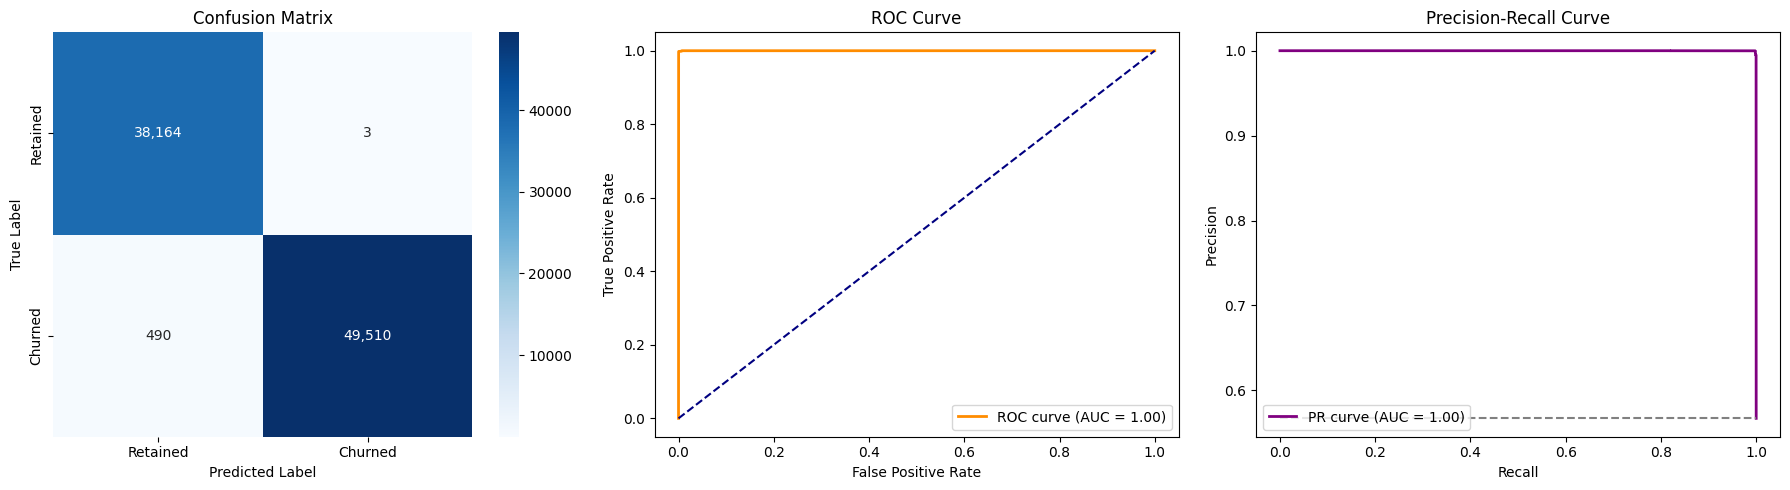

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# Build Full Pipeline with Classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

# Train Model
print("Training Random Forest Model on behavioral data...")
model_pipeline.fit(X_train, y_train)
print("Training Complete!\n")

# Generate Predictions & Probabilities
y_pred = model_pipeline.predict(X_test)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]

#  Print Classification Report
print("="*55)
print("             CLASSIFICATION METRICS REPORT             ")
print("="*55)
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

#  Plot Confusion Matrix, ROC-AUC Curve, and Precision-Recall Curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt=',d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned']
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
axes[2].plot([0, 1], [y_test.mean(), y_test.mean()], color='gray', linestyle='--')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

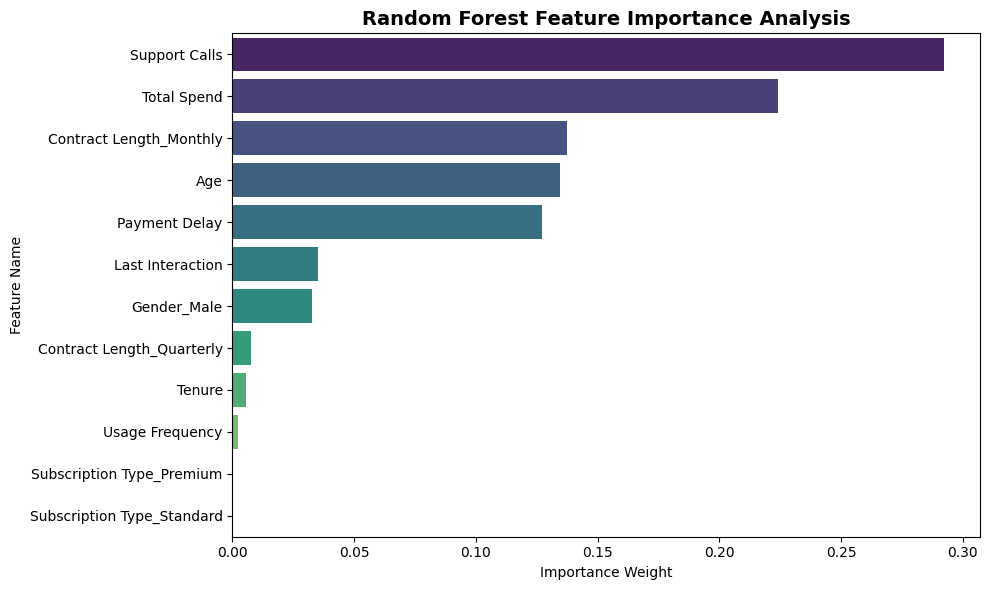


--- Top Behavioral Predictors of Churn ---
                Feature  Importance
          Support Calls    0.292492
            Total Spend    0.224165
Contract Length_Monthly    0.137634
                    Age    0.134403
          Payment Delay    0.127336


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature names after One-Hot Encoding
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_features))
all_feature_names = num_features + encoded_cat_cols

# Extract feature importances from the Random Forest model
importances = model_pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Random Forest Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Importance Weight')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# Display top drivers
print("\n--- Top Behavioral Predictors of Churn ---")
print(feature_importance_df.head(5).to_string(index=False))

Model pipeline saved as 'churn_model_pipeline.pkl'
Feature importance chart saved as 'feature_importance.png'


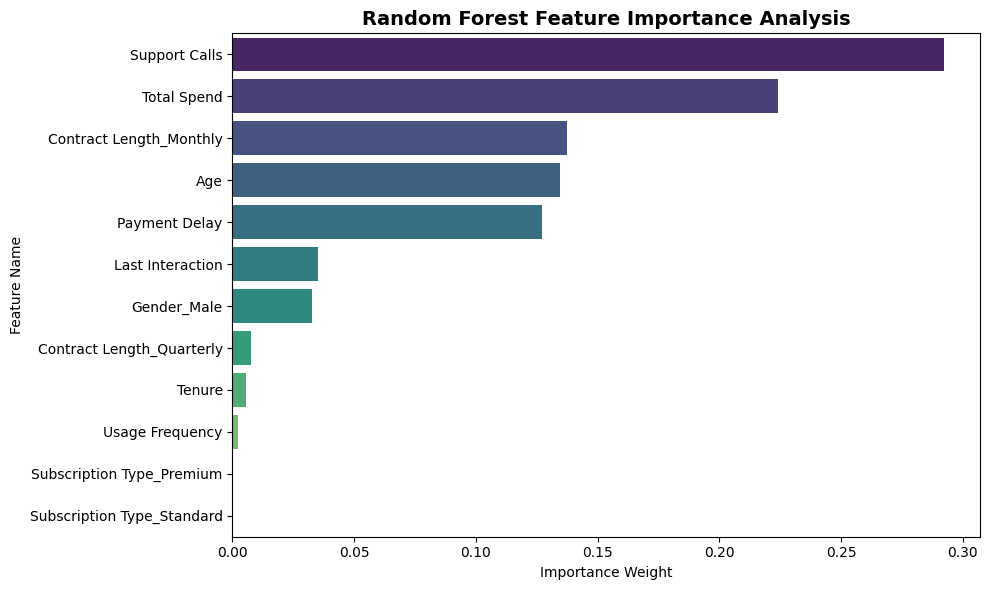

In [ ]:
import joblib

#  Save the full trained model pipeline
joblib.dump(model_pipeline, 'churn_model_pipeline.pkl')
print("Model pipeline saved as 'churn_model_pipeline.pkl'")

#  Save high-resolution feature importance plot for your README
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Random Forest Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Importance Weight')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("Feature importance chart saved as 'feature_importance.png'")

In [ ]:
# Save evaluation metrics figure
fig.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')
print("Evaluation metrics plot saved as 'evaluation_metrics.png'")

Evaluation metrics plot saved as 'evaluation_metrics.png'


**The model achieves an artificially high 99.44% accuracy because the dataset (customer_churn_dataset-training-master.csv) is semi-synthetic and contains deterministic decision rules embedded directly into the features. Specifically, 100% of users on a Monthly Contract ($87,104$ cases) and 100% of users with a Payment Delay > 20 days ($52,190$ cases) are labeled as churned, while 99.1% of customers making > 4 Support Calls ($120,446$ cases) also churned. Combined, these three explicit rules cover nearly half of the entire dataset ($208,592$ rows) with a 99.37% churn rate. Because tree-based models like Random Forests easily isolate these hard boundary thresholds during splitting, the model effectively learns a set of lookup rules rather than complex behavioral relationships, producing a near-perfect confusion matrix ($38,164$ True Retained, $49,510$ True Churned, and only $493$ misclassifications out of $88,167$ test samples).**